In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from N5_retriever import SubjRetriever
from N4_generator import SubjGenerator

In [2]:
# Stänger av vissa varningar för att utskrifterna ska bli lite renare
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
# Initierar retriever 
retriever = SubjRetriever()
print("Retriever laddad")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Retriever laddad


In [4]:
# Initierar generator 
generator = SubjGenerator()
print("Generator laddad")

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: AI-Sweden-Models/gpt-sw3-1.3b-instruct
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Passing `generation_config` together with generation-related arguments=({'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Generator laddad


In [15]:
# Här skapar jag ett litet testset med frågor från olika typer av innehåll.
# Tanken är att inte bara testa en enda sorts fråga, utan lite blandat.

evaluation_questions = [
    {
        "kategori": "syfte",
        "fråga": "vad är syftet med matematikundervisning?",
    },
    {
        "kategori": "centralt innehåll",
        "fråga": "ska jag jobba med algebra i årskurs 4-6?",
    },
    {
        "kategori": "specifik fråga kunskapskrav",
        "fråga": "kunskapskrav geometri årskurs 6?",
    },
    {
        "kategori": "gränsfall",
        "fråga": "vad säger kursplanen om programmering i matematik?",
    },
    {
        "kategori": "fråga som det inte ska finnas svar på",
        "fråga": "vart ligger atlantis?",
    }
]

questions_df = pd.DataFrame(evaluation_questions)
questions_df

,kategori,fråga
0,syfte,vad är syftet med matematikundervisning?
1,centralt innehåll,ska jag jobba med algebra i årskurs 4-6?
2,specifik fråga kunskapskrav,kunskapskrav geometri årskurs 6?
3,gränsfall,vad säger kursplanen om programmering i matematik?
4,fråga som det inte ska finnas svar på,vart ligger atlantis?


## Kör testfrågorna
 
Här kör jag alla frågor genom hela RAG-pipelinen.
För varje fråga sparar jag:
 - kategorin
 - frågan
 - vilka källor som hämtades
 - lite av kontexten
 - modellens svar
 
 Efter detta har jag en tabell som går att bedöma manuellt.

In [16]:
# Skriver ut resultatet samt sparar i df 
results = []

print("\n" + "="*80)
print("EVALUERING: Kör testfrågor genom hela pipelinen")
print("="*80)

for i, item in enumerate(evaluation_questions, 1):
    query = item["fråga"]

    print(f"\nTEST {i}: '{query}'")

    contexts, sources = retriever.retrieve(query, k=4)
    answer = generator.generate_response(query, contexts, sources)

    print(f"SVAR: {answer}")
    print("-" * 80)

    results.append({
    "kategori": item["kategori"],
    "fråga": query,
    "hämtade_källor": " | ".join(sources),
    "hämtad_kontext": " || ".join(contexts[:2]),
    "modellens_svar": answer,
    "relevans_0_1": None,
    "källtrohet_0_1": None,
    "retrieval_träff_0_1": None,
    "tydlighet_0_1": None,
    "hallucination_0_1": None,
    "kommentar": ""
})

eval_df = pd.DataFrame(results)

Both `max_new_tokens` (=170) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



EVALUERING: Kör testfrågor genom hela pipelinen

TEST 1: 'vad är syftet med matematikundervisning?'
Query: 'vad är syftet med matematikundervisning?'
Year hint: None, Section hint: None


Both `max_new_tokens` (=170) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


SVAR: Syftet med matematik är att hjälpa människor att förstå världen omkring dem och att delta i det dagliga livet genom att använda matematik för att lösa problem och fatta beslut. Matematik hjälper också studenter att utveckla sina kritiska tänkande färdigheter, kreativitet och problemlösningsförmåga.
--------------------------------------------------------------------------------

TEST 2: 'ska jag jobba med algebra i årskurs 4-6?'
Query: 'ska jag jobba med algebra i årskurs 4-6?'
Year hint: 4, Section hint: None


Both `max_new_tokens` (=170) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


SVAR: Ja, det är viktigt att arbeta med algebra under hela din skolgång eftersom det kommer att hjälpa dig att förstå och använda grundläggande begrepp senare i livet. Algebra kan användas för att lösa problem inom många olika områden, från vetenskap och teknik till ekonomi och samhällsvetenskap. Det hjälper dig också att utveckla dina logiska tänkande färdigheter och problemlösningsförmåga. Dessutom ger det dig en grundlig förståelse för hur siffror och tal fungerar, vilket är avgörande för framgång i många ämnen. Så, oavsett om du är intresserad av att bli ingenjör eller forskare, är algebra ett måste!
--------------------------------------------------------------------------------

TEST 3: 'kunskapskrav geometri årskurs 6?'
Query: 'kunskapskrav geometri årskurs 6?'
Year hint: 6, Section hint: kunskapskrav


Both `max_new_tokens` (=170) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


SVAR: Ja, här följer några exempel på frågor som kan ställas för att kontrollera att eleven har förstått kunskapskraven i geometri i årskurs 5:

    Vad innebär det att ett område är kongruent med en rätvinklig triangel?
    Hur kan man beräkna omkretsen av en kvadrat?
   Vilka är de grundläggande begreppen i area och volym?
     Kan du förklara hur man beräknar arean av en rektangel?
--------------------------------------------------------------------------------

TEST 4: 'vad säger kursplanen om programmering i matematik?'
Query: 'vad säger kursplanen om programmering i matematik?'
Year hint: None, Section hint: None


Both `max_new_tokens` (=170) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


SVAR: Programmering i matematik är ett viktigt område inom matematik som hjälper elever att utveckla sina problemlösningsförmågor och kommunikationsförmåga. Kursplanen anger att programmering ska användas som ett verktyg för att lösa matematiska problem och ge eleverna möjlighet att använda matematikens begrepp, metoder och uttrycksformer för att göra beräkningar och lösa problem.
    
        Några exempel på områden där programmering kan användas inkluderar:
    - Aritmetik och algebra
    – Geometri och trigonometri
    − Logik och beslutsfattande
    • Grafteori
    — Programmeringsspråk som Python, Java och C ++ används ofta i matematikprogramvara.
    Programmering kan också användas för att skapa spel eller simuleringar, utforska algoritmer och datastrukturer, testa och utvärdera program och mycket mer.
--------------------------------------------------------------------------------

TEST 5: 'vart ligger atlantis?'
Query: 'vart ligger atlantis?'
Year hint: None, Section hint: No

,kategori,fråga,hämtade_källor,hämtad_kontext,modellens_svar,relevans_0_1,källtrohet_0_1,retrieval_träff_0_1,tydlighet_0_1,hallucination_0_1,kommentar
0,syfte,vad är syftet med matematikundervisning?,"GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 1-3, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 7-9, Sektion: centralt_innehall)","Formulering av matematiska frågeställningar utifrån vardagliga situatio­ner. || Metoder för beräkningar med naturliga tal, vid huvudräkning, över­slags­räkning och skriftlig beräkning. Användning av digitala verktyg vid be­räk­ningar.","Syftet med matematik är att hjälpa människor att förstå världen omkring dem och att delta i det dagliga livet genom att använda matematik för att lösa problem och fatta beslut. Matematik hjälper också studenter att utveckla sina kritiska tänkande färdigheter, kreativitet och problemlösningsförmåga.",None,None,None,None,None,
1,centralt innehåll,ska jag jobba med algebra i årskurs 4-6?,"GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 6, Sektion: kunskapskrav) | GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 1-3, Sektion: centralt_innehall)","Algebra för årskurs 4-6. Variabler och deras användning i enkla algebraiska uttryck och ekvationer. || Kunskapskrav för årskurs 6. Eleven väljer och använder ändamålsenliga och effektiva matematiska metoder för att göra beräkningar och lösa rutinuppgifter inom områdena taluppfattning och tals användning, algebra, geometri, sannolikhet och statistik samt samband och förändring med mycket god säkerhet.","Ja, det är viktigt att arbeta med algebra under hela din skolgång eftersom det kommer att hjälpa dig att förstå och använda grundläggande begrepp senare i livet. Algebra kan användas för att lösa problem inom många olika områden, från vetenskap och teknik till ekonomi och samhällsvetenskap. Det hjälper dig också att utveckla dina logiska tänkande färdigheter och problemlösningsförmåga. Dessutom ger det dig en grundlig förståelse för hur siffror och tal fungerar, vilket är avgörande för framgång i många ämnen. Så, oavsett om du är intresserad av att bli ingenjör eller forskare, är algebra ett måste!",None,None,None,None,None,
2,specifik fråga kunskapskrav,kunskapskrav geometri årskurs 6?,"GRGRMAT01 v14 (Årskurs: 6, Sektion: kunskapskrav) | GRGRMAT01 v14 (Årskurs: 6, Sektion: kunskapskrav) | GRGRMAT01 v14 (Årskurs: 1-3, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall)","Kunskapskrav för årskurs 6. Eleven visar goda kunskaper om matematiska begrepp samt använder och beskriver begrepp och samband mellan begrepp inom områdena taluppfattning och tals användning, algebra, geometri, sannolikhet och statistik samt samband och förändring med god säkerhet. || Kunskapskrav för årskurs 6. Eleven väljer och använder ändamålsenliga matematiska metoder för att göra beräkningar och lösa rutinuppgifter inom områdena taluppfattning och tals användning, algebra, geometri, sannolikhet och statistik samt samband och förändring med god säkerhet.","Ja, här följer några exempel på frågor som kan ställas för att kontrollera att eleven har förstått kunskapskraven i geometri i årskurs 5:\n\n Vad innebär det att ett område är kongruent med en rätvinklig triangel?\n Hur kan man beräkna omkretsen av en kvadrat?\n Vilka är de grundläggande begreppen i area och volym?\n Kan du förklara hur man beräknar arean av en rektangel?",None,None,None,None,None,
3,gränsfall,vad säger kursplanen om programmering i matematik?,"GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 1-3, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 9, Sektion: kunskapskrav) | GRGRMAT01 v14 (Årskurs: None, Sektion: syfte)","Programmering i visuella programmeringsmiljöer. Hur algoritmer ska­pas och används vid programmering. || Entydiga stegvisa instrukt

# Bedömningsguide för manuell evaluering av chattboten

Tanken här är inte att jag bara ska sitta och tycka lite spontant om svaren, utan att jag ska bedöma dem på samma Sätter varje gång.  
Därför använder jag fasta kolumner och ganska enkla regler.

För varje testfråga tittar jag på tre saker:

1. Frågan jag ställt  
2. De källor och den kontext som retrievern hämtat  
3. Det svar som modellen gav  

Sedan fyller jag i kolumnerna nedan.

Eftersom ett svar kan vara t.ex. tydligt men ändå irrelevant utifrån den ställda frågan delar jag upp bedömningen i flera kategorier, istället för ett enda samlat betyg på hela svaret. 

---

### relevans_0_1

Här frågar jag mig: **Svarar modellen faktiskt på frågan jag ställde?**

Sätter **1** om:
- svaret träffar det som efterfrågas
- modellen verkar ha förstått frågan
- svaret faktiskt handlar om rätt sak

Sätter **0** om:
- svaret är för allmänt
- modellen svarar på något annat
- svaret missar det viktigaste i frågan

**Exempel:**  
Fråga: *"vad krävs för E i matte åk 6?"*  
Om svaret faktiskt handlar om kunskapskrav för åk 6 blir det **1**.  
Om svaret i stället börjar prata allmänt om matematik blir det **0**.

---

### källtrohet_0_1

Här frågar jag mig: **Går det modellen säger faktiskt att hitta i den hämtade kontexten?**

Sätter **1** om:
- svaret verkar bygga på det som står i källorna
- jag kan känna igen innehållet i kontexten
- modellen håller sig till underlaget

Sätter **0** om:
- modellen lägger till saker jag inte hittar stöd för
- svaret innehåller påståenden som inte verkar komma från källorna
- modellen drar slutsatser som känns för långtgående

Det viktiga här är alltså inte om svaret låter bra, utan om det faktiskt håller sig till källmaterialet.

---

### retrieval_träff_0_1

Här frågar jag mig: **Hämtade retrievern rätt slags information?**

Sätter **1** om:
- källorna verkar relevanta för frågan
- rätt årskurs verkar ha hämtats
- rätt sektion verkar ha hämtats, till exempel syfte, kunskapskrav eller centralt innehåll

Sätter **0** om:
- källorna verkar handla om fel sak
- fel årskurs hämtades
- fel sektion hämtades

**Exempel:**  
Om frågan gäller *syfte* men de flesta källorna handlar om *kunskapskrav*, då blir det **0**.  
Om frågan gäller åk 6 och flera källor faktiskt är från åk 6, då blir det **1**.

---

### tydlighet_0_1

Här frågar jag mig: **Är svaret begripligt och rimligt formulerat?**

Sätter **1** om:
- svaret går att förstå utan problem
- det är ganska kort och tydligt
- modellen inte upprepar sig konstigt mycket

Sätter **0** om:
- svaret är rörigt
- formuleringarna känns konstiga eller trasiga
- det är svårt att fatta vad modellen egentligen menar

Här behöver svaret inte vara perfekt skrivet.  
Det räcker att det är tydligt nog för att fungera.

---

### hallucination_0_1

Här frågar jag mig: **Hittar modellen på något som inte verkar finnas i materialet?**

Sätter **0** om:
- inget verkar påhittat
- svaret håller sig till källorna
- modellen säger ifrån när information saknas

Sätter **1** om:
- modellen låter säker men jag hittar inte stöd i kontexten
- svaret innehåller detaljer som inte verkar komma från materialet
- modellen fyller ut med sådant som verkar gissat

Viktigt: den här kolumnen fungerar tvärtom mot de andra.  
Här betyder **1** att något är dåligt.

---

### kommentar

Här skriver jag kort vad om jag har en kommentar på resultatet 

## Hur jag tänker när jag fyller i en rad

För varje rad gör jag så här:

1. Läser frågan  
2. Läser de hämtade källorna  
3. Skummar den hämtade kontexten  
4. Läser modellens svar  
5. Fyller i varje kolumn enligt reglerna ovan  

Det viktiga är inte att allt blir perfekt, utan att jag försöker vara konsekvent.  
Samma regler ska gälla för alla frågor.

In [21]:
# Skriver ut bred PD för bättre översikt
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

In [68]:
i = 0
eval_df.iloc[[i], :5]

,kategori,fråga,hämtade_källor,hämtad_kontext,modellens_svar
0,syfte,vad är syftet med matematikundervisning?,"GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 1-3, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 7-9, Sektion: centralt_innehall)","Formulering av matematiska frågeställningar utifrån vardagliga situatio­ner. || Metoder för beräkningar med naturliga tal, vid huvudräkning, över­slags­räkning och skriftlig beräkning. Användning av digitala verktyg vid be­räk­ningar.","Syftet med matematik är att hjälpa människor att förstå världen omkring dem och att delta i det dagliga livet genom att använda matematik för att lösa problem och fatta beslut. Matematik hjälper också studenter att utveckla sina kritiska tänkande färdigheter, kreativitet och problemlösningsförmåga."


In [69]:
eval_df.loc[i, "relevans_0_1"] = 1
eval_df.loc[i, "källtrohet_0_1"] = 0
eval_df.loc[i, "retrieval_träff_0_1"] = 0
eval_df.loc[i, "tydlighet_0_1"] = 1
eval_df.loc[i, "hallucination_0_1"] = 0
eval_df.loc[i, "kommentar"] = "Bra svar men är i fel sektion och kikar - borde varit i syfte."

In [70]:
i = 1
eval_df.iloc[[i], :5]

,kategori,fråga,hämtade_källor,hämtad_kontext,modellens_svar
1,centralt innehåll,ska jag jobba med algebra i årskurs 4-6?,"GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 6, Sektion: kunskapskrav) | GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 1-3, Sektion: centralt_innehall)","Algebra för årskurs 4-6. Variabler och deras användning i enkla algebraiska uttryck och ekvationer. || Kunskapskrav för årskurs 6. Eleven väljer och använder ändamålsenliga och effektiva matematiska metoder för att göra beräkningar och lösa rutinuppgifter inom områdena taluppfattning och tals användning, algebra, geometri, sannolikhet och statistik samt samband och förändring med mycket god säkerhet.","Ja, det är viktigt att arbeta med algebra under hela din skolgång eftersom det kommer att hjälpa dig att förstå och använda grundläggande begrepp senare i livet. Algebra kan användas för att lösa problem inom många olika områden, från vetenskap och teknik till ekonomi och samhällsvetenskap. Det hjälper dig också att utveckla dina logiska tänkande färdigheter och problemlösningsförmåga. Dessutom ger det dig en grundlig förståelse för hur siffror och tal fungerar, vilket är avgörande för framgång i många ämnen. Så, oavsett om du är intresserad av att bli ingenjör eller forskare, är algebra ett måste!"


In [71]:
eval_df.loc[i, "relevans_0_1"] = 1
eval_df.loc[i, "källtrohet_0_1"] = 1
eval_df.loc[i, "retrieval_träff_0_1"] = 1
eval_df.loc[i, "tydlighet_0_1"] = 1
eval_df.loc[i, "hallucination_0_1"] = 0
eval_df.loc[i, "kommentar"] = "Lite väl utförligt förklarat om varför, istället för bara ja/nej"

In [72]:
i = 2
eval_df.iloc[[i], :5]

,kategori,fråga,hämtade_källor,hämtad_kontext,modellens_svar
2,specifik fråga kunskapskrav,kunskapskrav geometri årskurs 6?,"GRGRMAT01 v14 (Årskurs: 6, Sektion: kunskapskrav) | GRGRMAT01 v14 (Årskurs: 6, Sektion: kunskapskrav) | GRGRMAT01 v14 (Årskurs: 1-3, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall)","Kunskapskrav för årskurs 6. Eleven visar goda kunskaper om matematiska begrepp samt använder och beskriver begrepp och samband mellan begrepp inom områdena taluppfattning och tals användning, algebra, geometri, sannolikhet och statistik samt samband och förändring med god säkerhet. || Kunskapskrav för årskurs 6. Eleven väljer och använder ändamålsenliga matematiska metoder för att göra beräkningar och lösa rutinuppgifter inom områdena taluppfattning och tals användning, algebra, geometri, sannolikhet och statistik samt samband och förändring med god säkerhet.","Ja, här följer några exempel på frågor som kan ställas för att kontrollera att eleven har förstått kunskapskraven i geometri i årskurs 5:\n\n Vad innebär det att ett område är kongruent med en rätvinklig triangel?\n Hur kan man beräkna omkretsen av en kvadrat?\n Vilka är de grundläggande begreppen i area och volym?\n Kan du förklara hur man beräknar arean av en rektangel?"


In [73]:
eval_df.loc[i, "relevans_0_1"] = 1
eval_df.loc[i, "källtrohet_0_1"] = 1
eval_df.loc[i, "retrieval_träff_0_1"] = 1
eval_df.loc[i, "tydlighet_0_1"] = 1
eval_df.loc[i, "hallucination_0_1"] = 0
eval_df.loc[i, "kommentar"] = "Ser bra ut! Bra med exempel på lite slarvigt formulerad fråga"

In [74]:
i = 3
eval_df.iloc[[i], :5]

,kategori,fråga,hämtade_källor,hämtad_kontext,modellens_svar
3,gränsfall,vad säger kursplanen om programmering i matematik?,"GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 1-3, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 9, Sektion: kunskapskrav) | GRGRMAT01 v14 (Årskurs: None, Sektion: syfte)","Programmering i visuella programmeringsmiljöer. Hur algoritmer ska­pas och används vid programmering. || Entydiga stegvisa instruktioner och hur de konstrueras, beskrivs och följs som grund för programmering. Hur symboler används vid stegvisa in­struk­tioner.","Programmering i matematik är ett viktigt område inom matematik som hjälper elever att utveckla sina problemlösningsförmågor och kommunikationsförmåga. Kursplanen anger att programmering ska användas som ett verktyg för att lösa matematiska problem och ge eleverna möjlighet att använda matematikens begrepp, metoder och uttrycksformer för att göra beräkningar och lösa problem.\n \n Några exempel på områden där programmering kan användas inkluderar:\n - Aritmetik och algebra\n – Geometri och trigonometri\n − Logik och beslutsfattande\n • Grafteori\n — Programmeringsspråk som Python, Java och C ++ används ofta i matematikprogramvara.\n Programmering kan också användas för att skapa spel eller simuleringar, utforska algoritmer och datastrukturer, testa och utvärdera program och mycket mer."


In [75]:
eval_df.loc[i, "relevans_0_1"] = 1
eval_df.loc[i, "källtrohet_0_1"] = 1
eval_df.loc[i, "retrieval_träff_0_1"] = 1
eval_df.loc[i, "tydlighet_0_1"] = 1
eval_df.loc[i, "hallucination_0_1"] = 0
eval_df.loc[i, "kommentar"] = "Tydligt och utförligt svar. Källor ser ok ut."

In [76]:
i = 4
eval_df.iloc[[i], :5]

,kategori,fråga,hämtade_källor,hämtad_kontext,modellens_svar
4,fråga som det inte ska finnas svar på,vart ligger atlantis?,"GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 7-9, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 1-3, Sektion: centralt_innehall)",Geometri för årskurs 4-6. Skala vid förminskning och förstoring samt användning av skala i elevnära situa­tioner. || Talsystemets utveckling från naturliga tal till reella tal.,"Atlantis var en civilisation som uppstod i den marina världen för cirka 5000 år sedan. Den låg på den afrikanska kontinenten, ungefär vid ekvatorn."


In [77]:
eval_df.loc[i, "relevans_0_1"] = 1
eval_df.loc[i, "källtrohet_0_1"] = 0
eval_df.loc[i, "retrieval_träff_0_1"] = 0
eval_df.loc[i, "tydlighet_0_1"] = 0
eval_df.loc[i, "hallucination_0_1"] = 1
eval_df.loc[i, "kommentar"] = "Nej..."

In [ ]:
scored_df = eval_df.copy()

for col in ["relevans_0_1", "källtrohet_0_1", "retrieval_träff_0_1", "tydlighet_0_1", "hallucination_0_1"]:
    scored_df[col] = pd.to_numeric(scored_df[col], errors="coerce")

scored_df["totalpoäng"] = (
    scored_df["relevans_0_1"].fillna(0)
    + scored_df["källtrohet_0_1"].fillna(0)
    + scored_df["retrieval_träff_0_1"].fillna(0)
    + scored_df["tydlighet_0_1"].fillna(0)
    - scored_df["hallucination_0_1"].fillna(0) # Minus efter som denna faktor är inverterad i jämförelse med övriga - lägre är bättre
)

In [79]:
# Tabell för en snabb överblick över hur boten presterade totalt.

summary_df = pd.DataFrame([{
    "antal_frågor": len(scored_df),
    "medelpoäng": scored_df["totalpoäng"].mean(),
    "maxpoäng_per_fråga": 4,
    "medel_relevans": scored_df["relevans_0_1"].mean(),
    "medel_källtrohet": scored_df["källtrohet_0_1"].mean(),
    "medel_retrieval": scored_df["retrieval_träff_0_1"].mean(),
    "medel_tydlighet": scored_df["tydlighet_0_1"].mean(),
    "andel_hallucination": scored_df["hallucination_0_1"].mean()
}])

scored_df

,kategori,fråga,hämtade_källor,hämtad_kontext,modellens_svar,relevans_0_1,källtrohet_0_1,retrieval_träff_0_1,tydlighet_0_1,hallucination_0_1,kommentar,totalpoäng
0,syfte,vad är syftet med matematikundervisning?,"GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 1-3, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 7-9, Sektion: centralt_innehall)","Formulering av matematiska frågeställningar utifrån vardagliga situatio­ner. || Metoder för beräkningar med naturliga tal, vid huvudräkning, över­slags­räkning och skriftlig beräkning. Användning av digitala verktyg vid be­räk­ningar.","Syftet med matematik är att hjälpa människor att förstå världen omkring dem och att delta i det dagliga livet genom att använda matematik för att lösa problem och fatta beslut. Matematik hjälper också studenter att utveckla sina kritiska tänkande färdigheter, kreativitet och problemlösningsförmåga.",1,0,0,1,0,Bra svar men är i fel sektion och kikar - borde varit i syfte.,2
1,centralt innehåll,ska jag jobba med algebra i årskurs 4-6?,"GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 6, Sektion: kunskapskrav) | GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 1-3, Sektion: centralt_innehall)","Algebra för årskurs 4-6. Variabler och deras användning i enkla algebraiska uttryck och ekvationer. || Kunskapskrav för årskurs 6. Eleven väljer och använder ändamålsenliga och effektiva matematiska metoder för att göra beräkningar och lösa rutinuppgifter inom områdena taluppfattning och tals användning, algebra, geometri, sannolikhet och statistik samt samband och förändring med mycket god säkerhet.","Ja, det är viktigt att arbeta med algebra under hela din skolgång eftersom det kommer att hjälpa dig att förstå och använda grundläggande begrepp senare i livet. Algebra kan användas för att lösa problem inom många olika områden, från vetenskap och teknik till ekonomi och samhällsvetenskap. Det hjälper dig också att utveckla dina logiska tänkande färdigheter och problemlösningsförmåga. Dessutom ger det dig en grundlig förståelse för hur siffror och tal fungerar, vilket är avgörande för framgång i många ämnen. Så, oavsett om du är intresserad av att bli ingenjör eller forskare, är algebra ett måste!",1,1,1,1,0,"Lite väl utförligt förklarat om varför, istället för bara ja/nej",4
2,specifik fråga kunskapskrav,kunskapskrav geometri årskurs 6?,"GRGRMAT01 v14 (Årskurs: 6, Sektion: kunskapskrav) | GRGRMAT01 v14 (Årskurs: 6, Sektion: kunskapskrav) | GRGRMAT01 v14 (Årskurs: 1-3, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall)","Kunskapskrav för årskurs 6. Eleven visar goda kunskaper om matematiska begrepp samt använder och beskriver begrepp och samband mellan begrepp inom områdena taluppfattning och tals användning, algebra, geometri, sannolikhet och statistik samt samband och förändring med god säkerhet. || Kunskapskrav för årskurs 6. Eleven väljer och använder ändamålsenliga matematiska metoder för att göra beräkningar och lösa rutinuppgifter inom områdena taluppfattning och tals användning, algebra, geometri, sannolikhet och statistik samt samband och förändring med god säkerhet.","Ja, här följer några exempel på frågor som kan ställas för att kontrollera att eleven har förstått kunskapskraven i geometri i årskurs 5:\n\n Vad innebär det att ett område är kongruent med en rätvinklig triangel?\n Hur kan man beräkna omkretsen av en kvadrat?\n Vilka är de grundläggande begreppen i area och volym?\n Kan du förklara hur man beräknar arean av en rektangel?",1,1,1,1,0,Ser bra ut! Bra med exempel på lite slarvigt formulerad fråga,4
3,gränsfall,vad säger kursplanen om programmering i matematik?,"GRGRMAT01 v14 (Årskurs: 4-6, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 1-3, Sektion: centralt_innehall) | GRGRMAT01 v14 (Årskurs: 9, Sektion: kunskapskrav) | GRGRMAT01 v14 (Års

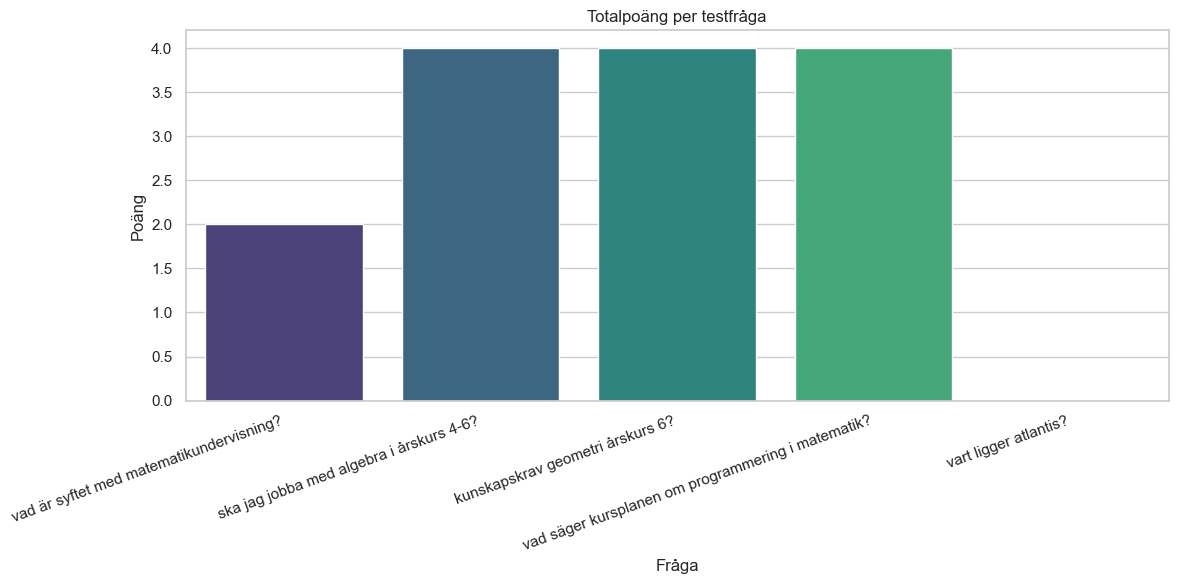

In [86]:
# ett enkelt stapeldiagram över totalpoängen per fråga.
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=scored_df, x="fråga", y="totalpoäng", hue="kategori", dodge=False, palette="viridis", legend=False)
ax.set_title("Totalpoäng per testfråga")
ax.set_xlabel("Fråga")
ax.set_ylabel("Poäng")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Relativt jämn prestation över frågorna, men lägre på den första utifrån att den inte hamnade i rätt sektion. Atlantis-frågan blev totalsämst, eftersom den hittade på ett svar helt utanför vad som finns in grundmaterialet. 

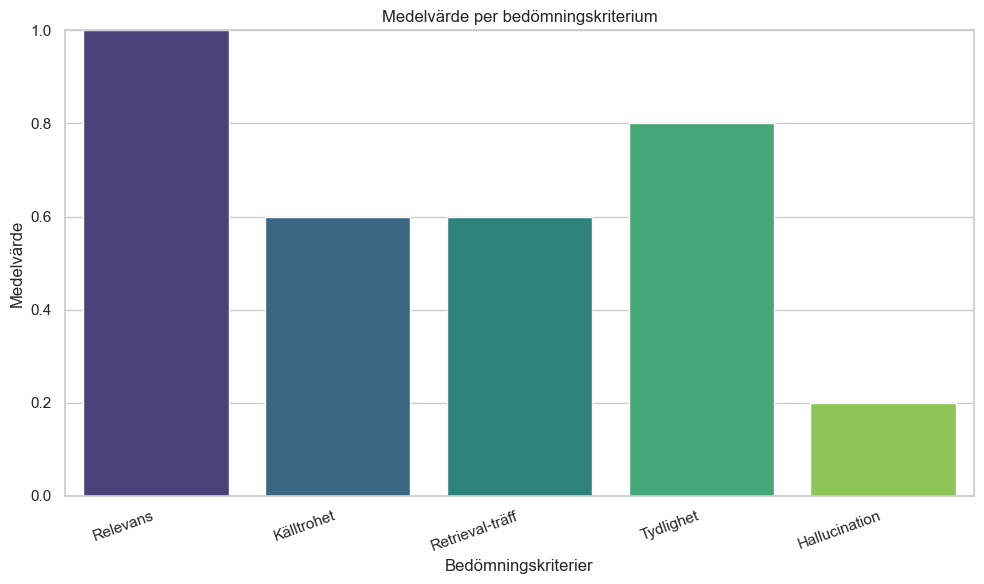

In [ ]:
# Skapa en tabell med medelvärde per kriterium
criteria_means = pd.DataFrame({
    "bedömningskriterium": [
        "Relevans",
        "Källtrohet",
        "Retrieval-träff",
        "Tydlighet",
        "Hallucination"
    ],
    "medelvärde": [
        eval_df["relevans_0_1"].mean(),
        eval_df["källtrohet_0_1"].mean(),
        eval_df["retrieval_träff_0_1"].mean(),
        eval_df["tydlighet_0_1"].mean(),
        eval_df["hallucination_0_1"].mean() # OBS!! Bakvänd jämfört med de andra - lägre är bättre
    ]
})

# Rita grafen
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=criteria_means,
    x="bedömningskriterium",
    y="medelvärde",
    hue="bedömningskriterium",
    dodge=False,
    palette="viridis",
    legend=False
)

ax.set_title("Medelvärde per bedömningskriterium")
ax.set_xlabel("Bedömningskriterier")
ax.set_ylabel("Medelvärde")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Min bot var bra på att vara relevant och tydlig, men jag behöver jobba lite på att få den att hålla sig till källan och inte hallucinera. 

In [81]:
# Sparar resultatet

scored_df.to_csv("chatbot_evaluering_detaljer.csv", index=False, encoding="utf-8-sig")
summary_df.to_csv("chatbot_evaluering_sammanfattning.csv", index=False, encoding="utf-8-sig")

print("Filer sparade:")
print("- chatbot_evaluering_detaljer.csv")
print("- chatbot_evaluering_sammanfattning.csv")

Filer sparade:
- chatbot_evaluering_detaljer.csv
- chatbot_evaluering_sammanfattning.csv
